      Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0         1          5 2015-07-31   5263        555     1      1            0   
1115      1          4 2015-07-30   5020        546     1      1            0   
2230      1          3 2015-07-29   4782        523     1      1            0   
3345      1          2 2015-07-28   5011        560     1      1            0   
4460      1          1 2015-07-27   6102        612     1      1            0   

      SchoolHoliday  
0                 1  
1115              1  
2230              1  
3345              1  
4460              1  
   WeekStart  WeeklySales  t
0 2012-12-31        19340  0
1 2013-01-07        32952  1
2 2013-01-14        25978  2
3 2013-01-21        33071  3
4 2013-01-28        28693  4
                            OLS Regression Results                            
Dep. Variable:            WeeklySales   R-squared:                       0.022
Model:                            OLS   Adj. R-sq

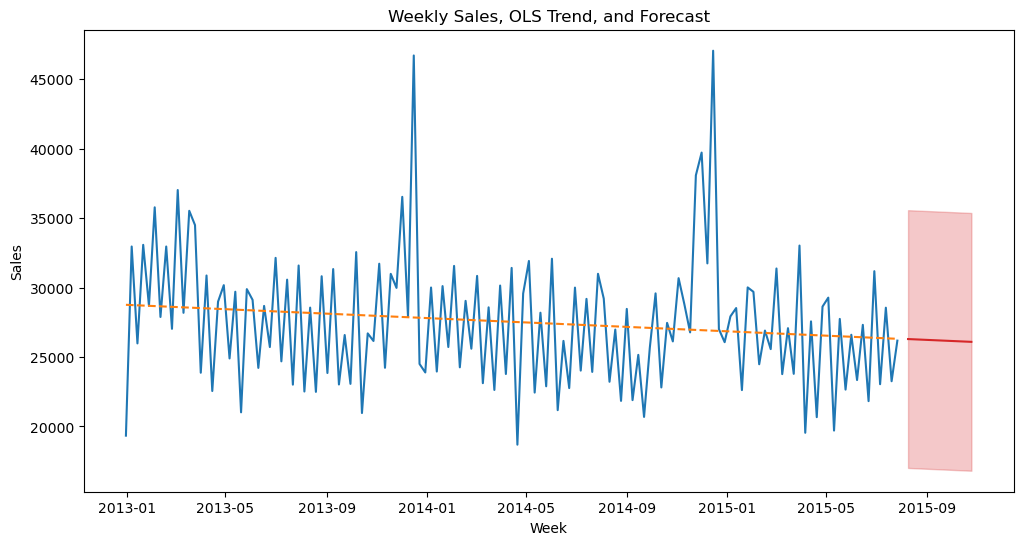

In [14]:
import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
try:
    import pmdarima as pm
except ImportError:
    pm = None

train = pd.read_csv("train.csv", parse_dates=["Date"], low_memory=False)
store = pd.read_csv("store.csv", low_memory=False)

# Select store 1 from TRAIN, not store.csv
data = train[train["Store"] == 1].copy()

# Remove closed days
data = data[(data["Open"] == 1) & (data["Sales"] > 0)]

print(data.head())

data['WeekStart'] = data['Date'].dt.to_period('W').apply(lambda r: r.start_time)

weekly = (
    data.groupby('WeekStart')['Sales']
        .sum()
        .reset_index()
        .rename(columns={'Sales': 'WeeklySales'})
        .sort_values('WeekStart')
        .reset_index(drop=True)
)

weekly['t'] = np.arange(len(weekly))

print(weekly.head())
#ols
X = sm.add_constant(weekly['t'])
ols = sm.OLS(weekly['WeeklySales'], X).fit()
print(ols.summary())

#promo
promo_sales = data[data['Promo'] == 1]['Sales'].dropna()
nopromo_sales = data[data['Promo'] == 0]['Sales'].dropna()

tstat, pval = stats.ttest_ind(promo_sales, nopromo_sales, equal_var=False)

print("\nT-statistic:", tstat)
print("P-value:", pval)

#forcasting
n_forecast_weeks = 12

if pm is not None:
    # Use pmdarima auto_arima model for forecasting
    arima = pm.auto_arima(weekly['WeeklySales'], seasonal=False, suppress_warnings=True, stepwise=True)
    
    fc, confint = arima.predict(n_periods=n_forecast_weeks, return_conf_int=True)
    
    # Create future weekly dates starting after last observed week
    future_index = pd.date_range(start=weekly['WeekStart'].iloc[-1] + pd.Timedelta(days=7), 
                                 periods=n_forecast_weeks, freq='W')
    
    # Create forecast DataFrame with predictions and confidence intervals
    fc_df = pd.DataFrame({
        'WeekStart': future_index,
        'Forecast': fc,
        'Lower': confint[:, 0],
        'Upper': confint[:, 1]
    })

else:
    # Use simple linear trend extrapolation as fallback
    
    slope = ols.params['t']
    intercept = ols.params['const']
    
    last_t = weekly['t'].iloc[-1]
    future_t = np.arange(last_t + 1, last_t + 1 + n_forecast_weeks)
    
    # Forecast sales using linear trend
    fc = intercept + slope * future_t
    
    # Residual standard deviation for prediction interval
    resid_std = ols.resid.std(ddof=1)
    
    # 95% confidence interval width (1.96 is z-score for 95%)
    ci_width = 1.96 * resid_std
    
    # Create future weekly dates starting after last observed week
    future_index = pd.date_range(start=weekly['WeekStart'].iloc[-1] + pd.Timedelta(days=7), 
                                 periods=n_forecast_weeks, freq='W')
    
    # Create forecast DataFrame with prediction and confidence interval bounds
    fc_df = pd.DataFrame({
        'WeekStart': future_index,
        'Forecast': fc,
        'Lower': fc - ci_width,
        'Upper': fc + ci_width
    })

print(fc_df.head())
#plot
plt.figure(figsize=(12, 6))

# Plot actual weekly sales
plt.plot(weekly['WeekStart'], weekly['WeeklySales'], label='Actual Weekly Sales')

# Plot OLS trend line
X = sm.add_constant(weekly['t'])  # Make sure X is defined before
plt.plot(weekly['WeekStart'], ols.predict(X), label='OLS trend', linestyle='--')
# Plot forecasted sales
plt.plot(fc_df['WeekStart'], fc_df['Forecast'], label='Forecast', color='C3')
# Fill confidence interval area
plt.fill_between(fc_df['WeekStart'], fc_df['Lower'], fc_df['Upper'], 
                 alpha=0.25, color='C3', label='95% Prediction Interval')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.title('Weekly Sales, OLS Trend, and Forecast')
plt.show()

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


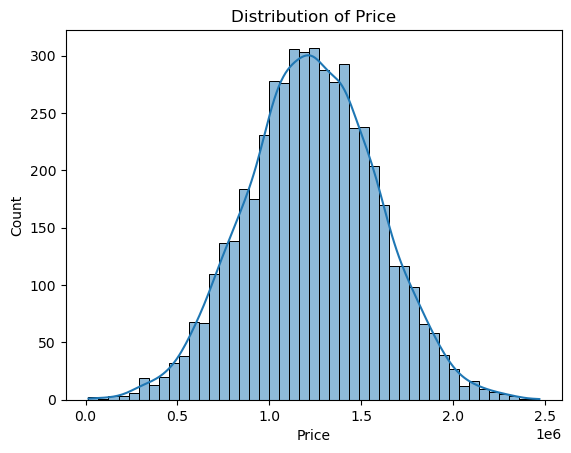

Skewness of Price: -0.002718064933559366


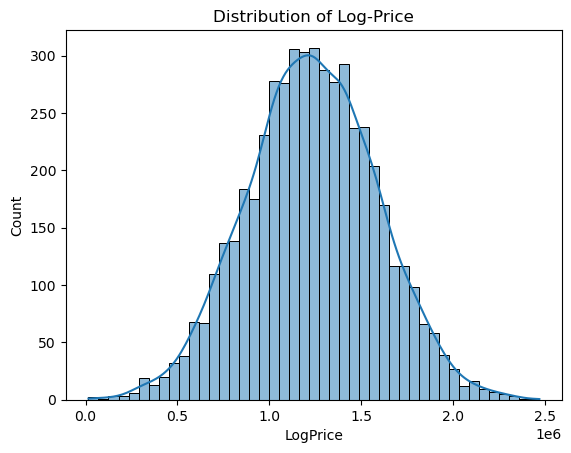

                            OLS Regression Results                            
Dep. Variable:               LogPrice   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.119e+04
Date:                Tue, 25 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:18:03   Log-Likelihood:                -64714.
No. Observations:                5000   AIC:                         1.294e+05
Df Residuals:                    4994   BIC:                         1.295e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

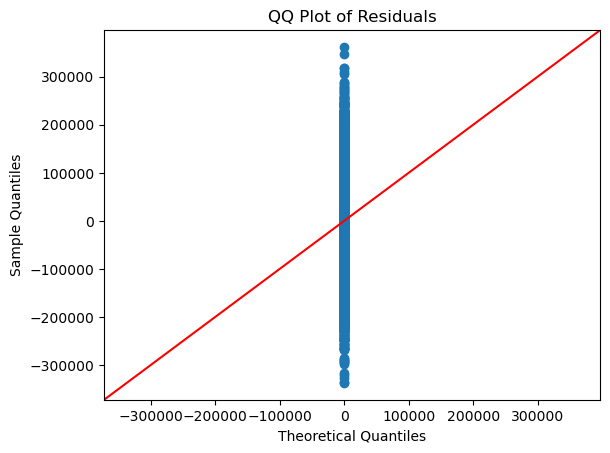

                            OLS Regression Results                            
Dep. Variable:               LogPrice   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.108e+04
Date:                Tue, 25 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:18:03   Log-Likelihood:                -64714.
No. Observations:                5000   AIC:                         1.294e+05
Df Residuals:                    4994   BIC:                         1.295e+05
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

C:\Users\BC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\BC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\BC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.compat import lzip
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df=pd.read_csv("Housing.csv")
print(df.columns)
# 2. EDA: check missing values & distributions
print(df.isnull().sum())

# Distribution of Price (target)
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Price')
plt.show()

# Check skewness
print(f"Skewness of Price: {df['Price'].skew()}")

# Log-transform Price if skewed
if abs(df['Price'].skew()) > 1:
    df['LogPrice'] = np.log(df['Price'])
else:
    df['LogPrice'] = df['Price']

sns.histplot(df['LogPrice'], kde=True)
plt.title('Distribution of Log-Price')
plt.show()

# 3. Feature selection (numeric predictors, exclude Address)
features = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
            'Avg. Area Number of Bedrooms', 'Area Population']

X = df[features]
y = df['LogPrice']

# Add constant for intercept
X = sm.add_constant(X)

# 4. Fit baseline OLS model
model = sm.OLS(y, X).fit()

# Regression summary table (coefficients, SE, t, p, 95% CI)
print(model.summary())

# Extract coefficients table for better formatting
coef_df = pd.DataFrame({
    'coef': model.params,
    'std_err': model.bse,
    't': model.tvalues,
    'p_value': model.pvalues,
    'CI_lower': model.conf_int()[0],
    'CI_upper': model.conf_int()[1]
})
print(coef_df)

# 5. Diagnostics

# VIF check
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

# Breusch-Pagan test for heteroskedasticity
bp_test = sms.het_breuschpagan(model.resid, model.model.exog)
bp_labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(bp_labels, bp_test)))

# Residual normality test - Shapiro-Wilk
shapiro_test = stats.shapiro(model.resid)
print(f'Shapiro-Wilk test: statistic={shapiro_test.statistic}, p-value={shapiro_test.pvalue}')

# QQ plot
sm.qqplot(model.resid, line='45')
plt.title('QQ Plot of Residuals')
plt.show()

# 6. Remedies if problems

# If heteroskedasticity present (p-value < 0.05), use robust SE (HC3)
robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())

# 7. Predict expected Price for hypothetical houses

# Define 3 hypothetical feature profiles (replace with actual example values)
hypothetical = pd.DataFrame([
    {'const': 1, 'Avg. Area Income': 65000, 'Avg. Area House Age': 10, 'Avg. Area Number of Rooms': 7,
     'Avg. Area Number of Bedrooms': 4, 'Area Population': 30000},
    {'const': 1, 'Avg. Area Income': 85000, 'Avg. Area House Age': 20, 'Avg. Area Number of Rooms': 9,
     'Avg. Area Number of Bedrooms': 5, 'Area Population': 40000},
    {'const': 1, 'Avg. Area Income': 45000, 'Avg. Area House Age': 5, 'Avg. Area Number of Rooms': 5,
     'Avg. Area Number of Bedrooms': 3, 'Area Population': 25000}
])

# Predict log prices + 95% prediction intervals
predictions = model.get_prediction(hypothetical)
pred_summary = predictions.summary_frame(alpha=0.05)

# Convert log-price back to Price scale
pred_summary['mean_price'] = np.exp(pred_summary['mean'])
pred_summary['pi_lower_price'] = np.exp(pred_summary['obs_ci_lower'])
pred_summary['pi_upper_price'] = np.exp(pred_summary['obs_ci_upper'])

print(pred_summary[['mean_price', 'pi_lower_price', 'pi_upper_price']])



Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
Total rows: 541909
After removing cancellations: 532621
Missing CustomerID count: 134697
   YearMonth     Revenue
0 2010-12-01  572713.890
1 2011-01-01  569445.040
2 2011-02-01  447137.350
3 2011-03-01  595500.760
4 2011-04-01  469200.361


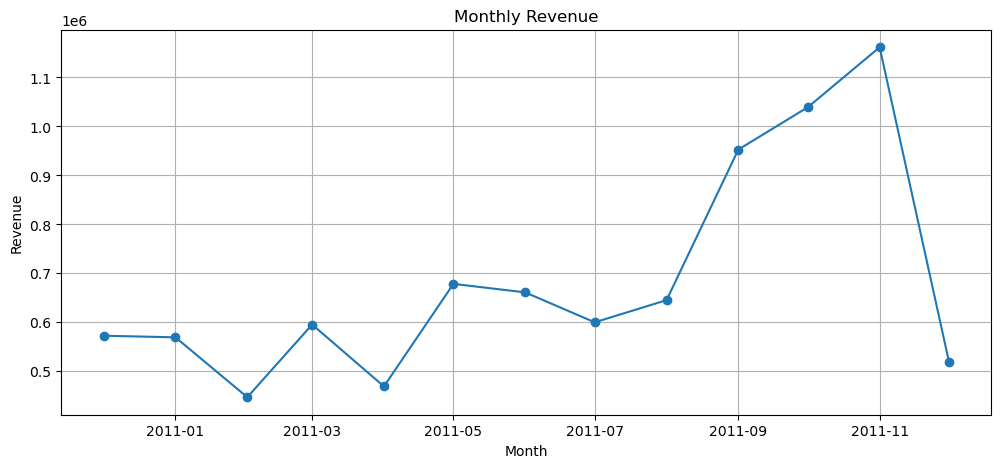

Expected quarterly revenue: 2,047,541.82
90% CI: [1,561,681.61, 2,759,999.66]
Standard deviation: 371,243.25
Probability revenue exceeds 2,252,296.00: 28.70%


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.utils import resample
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("Retail.csv", encoding='ISO-8859-1')
print(df.columns)
print("Total rows:", len(df))
# 2. Clean data
# Remove canceled transactions: InvoiceNo starting with 'C'
df_clean = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()
print("After removing cancellations:", len(df_clean))

# Drop missing CustomerID rows (or could impute)
missing_cust = df_clean['CustomerID'].isna().sum()
print(f"Missing CustomerID count: {missing_cust}")
df_clean = df_clean.dropna(subset=['CustomerID'])

# Convert CustomerID to int
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Ensure InvoiceDate is datetime dtype
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], errors='coerce')

# Drop any rows where InvoiceDate could not be converted (if any)
df_clean = df_clean.dropna(subset=['InvoiceDate'])

# 3. Compute revenue per transaction line and aggregate monthly
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Create Year-Month column for grouping
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly_revenue = df_clean.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].dt.to_timestamp()

print(monthly_revenue.head())

# Plot monthly revenue
plt.figure(figsize=(12,5))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'], marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

# 4. Estimate expected quarterly revenue (next 3 months after last month in data)

def bootstrap_quarterly_revenue(monthly_rev, n_bootstrap=1000, seed=42):
    np.random.seed(seed)
    quarterly_revenues = []
    for _ in range(n_bootstrap):
        # Sample 3 months with replacement and sum revenue
        sample = monthly_rev.sample(n=3, replace=True)['Revenue'].sum()
        quarterly_revenues.append(sample)
    quarterly_revenues = np.array(quarterly_revenues)
    
    mean_qr = np.mean(quarterly_revenues)
    std_qr = np.std(quarterly_revenues)
    ci_lower = np.percentile(quarterly_revenues, 5)
    ci_upper = np.percentile(quarterly_revenues, 95)
    
    return mean_qr, std_qr, ci_lower, ci_upper, quarterly_revenues

mean_qr, std_qr, ci_lower, ci_upper, qr_bootstrap_samples = bootstrap_quarterly_revenue(monthly_revenue)

print(f"Expected quarterly revenue: {mean_qr:,.2f}")
print(f"90% CI: [{ci_lower:,.2f}, {ci_upper:,.2f}]")
print(f"Standard deviation: {std_qr:,.2f}")

# Business target example: 10% above expected revenue
target = 1.1 * mean_qr
prob_exceed = np.mean(qr_bootstrap_samples > target)
print(f"Probability revenue exceeds {target:,.2f}: {prob_exceed:.2%}")

    



In [25]:
import pandas as pd
import numpy as np
df=pd.read_csv("Walmart.csv")
print(df.columns)


Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')


data.csv not found — using synthetic demo dataset.

=== CV RMSEs ===
   Split   Linear_RMSE      RF_RMSE
0      1  1.138232e-11  5315.360483
1      2  9.957825e-12  3601.138906
2      3  6.415001e-12  4255.787504
3      4  1.145927e-11  2676.951597
4      5  7.757409e-12  2460.289715

Linear Regression Coefficients:
Store          -3.068534e-12
Holiday_Flag   -1.518144e-12
Temperature     1.412941e-12
Fuel_Price     -1.053725e-12
CPI            -1.820537e-12
Unemployment    1.547642e-12
lag1           -4.959812e+03
lag2           -4.948583e+03
lag3           -4.671775e-12
roll3           8.904246e+03
dtype: float64

Random Forest Feature Importances:
Store           0.013912
Holiday_Flag    0.006317
Temperature     0.031108
Fuel_Price      0.038139
CPI             0.048767
Unemployment    0.037032
lag1            0.135176
lag2            0.177992
lag3            0.033858
roll3           0.477701
dtype: float64


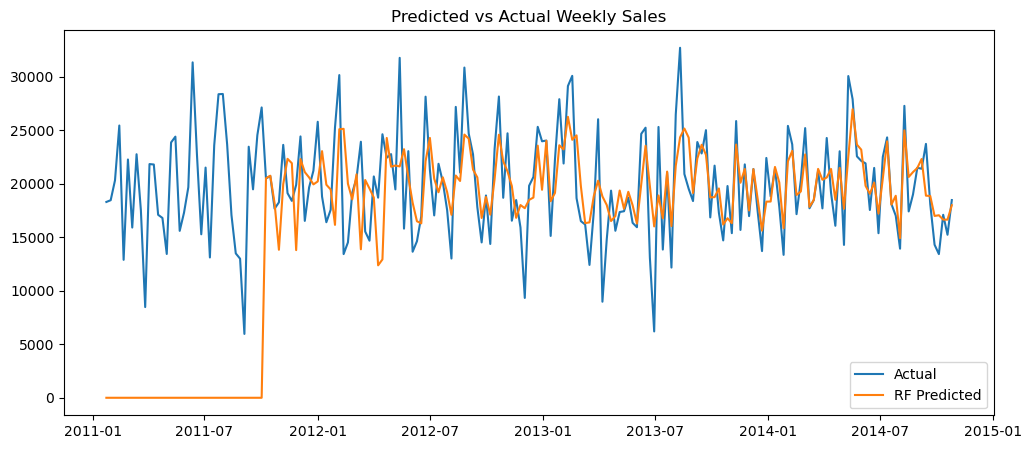

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# ===============================
# 1. Load Data (Synthetic Fallback)
# ===============================
try:
    df = pd.read_csv("data.csv")
except:
    print("data.csv not found — using synthetic demo dataset.")
    dates = pd.date_range(start="2011-01-01", periods=200, freq="W")
    df = pd.DataFrame({
        "Date": dates,
        "Store": np.random.randint(1, 5, size=len(dates)),
        "Weekly_Sales": np.random.normal(20000, 5000, size=len(dates)),
        "Holiday_Flag": np.random.randint(0, 2, size=len(dates)),
        "Temperature": np.random.normal(60, 20, size=len(dates)),
        "Fuel_Price": np.random.normal(3, 0.3, size=len(dates)),
        "CPI": np.random.normal(220, 5, size=len(dates)),
        "Unemployment": np.random.normal(7, 1, size=len(dates))
    })

df = df.sort_values("Date")

# ====================================
# 2. Feature Engineering
# ====================================
df["lag1"] = df["Weekly_Sales"].shift(1)
df["lag2"] = df["Weekly_Sales"].shift(2)
df["lag3"] = df["Weekly_Sales"].shift(3)
df["roll3"] = df["Weekly_Sales"].rolling(3).mean()

df = df.dropna()

features = ["Store", "Holiday_Flag", "Temperature", "Fuel_Price", "CPI",
            "Unemployment", "lag1", "lag2", "lag3", "roll3"]

X = df[features]
y = df["Weekly_Sales"]

# ====================================
# 3. TimeSeriesSplit Setup
# ====================================
tscv = TimeSeriesSplit(n_splits=5)

def time_series_cv_predict(model, X, y, tscv):
    preds = np.zeros(len(y))
    rmses = []
    for train_idx, test_idx in tscv.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred = model.predict(X.iloc[test_idx])
        preds[test_idx] = y_pred

        # FIXED LINE (RMSE)
        rmse = mean_squared_error(y.iloc[test_idx], y_pred) ** 0.5
        rmses.append(rmse)
    return preds, rmses

# ====================================
# 4. Build Models
# ====================================
lin_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)

# Run CV
lin_preds, lin_rmses = time_series_cv_predict(lin_model, X, y, tscv)
rf_preds, rf_rmses = time_series_cv_predict(rf_model, X, y, tscv)

# ====================================
# 5. Output Results
# ====================================
print("\n=== CV RMSEs ===")
print(pd.DataFrame({
    "Split": range(1, 6),
    "Linear_RMSE": lin_rmses,
    "RF_RMSE": rf_rmses
}))

print("\nLinear Regression Coefficients:")
lin_model.fit(X, y)
print(pd.Series(lin_model.named_steps["lr"].coef_, index=features))

print("\nRandom Forest Feature Importances:")
rf_model.fit(X, y)
print(pd.Series(rf_model.feature_importances_, index=features))

# ====================================
# 6. Plot Predicted vs Actual
# ====================================
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], y, label="Actual")
plt.plot(df["Date"], rf_preds, label="RF Predicted")
plt.legend()
plt.title("Predicted vs Actual Weekly Sales")
plt.show()

In [32]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Define Cohen's d function
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

# Load dataset
df = pd.read_csv("heart.csv")

# Check columns and target distribution
print(df.columns)
print(df['condition'].value_counts())

# Drop missing values
df = df.dropna()

# Confirm target is binary (0/1)
print(df['condition'].unique())

features = ['age', 'chol', 'trestbps', 'thalach']

results = []
for feat in features:
    group0 = df[df['condition'] == 0][feat]
    group1 = df[df['condition'] == 1][feat]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)  # Welch's t-test
    d = cohens_d(group1, group0)
    results.append({
        'feature': feat,
        'mean_condition_0': np.mean(group0),
        'mean_condition_1': np.mean(group1),
        't_stat': t_stat,
        'p_val': p_val,
        'cohen_d': d
    })

results_df = pd.DataFrame(results)

# Adjust p-values for multiple testing with Benjamini-Hochberg
results_df['p_adj'] = multipletests(results_df['p_val'], method='fdr_bh')[1]

print(results_df)


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')
condition
0    160
1    137
Name: count, dtype: int64
[0 1]
    feature  mean_condition_0  mean_condition_1    t_stat         p_val  \
0       age          52.64375         56.759124 -4.063564  6.203956e-05   
1      chol         243.49375        251.854015 -1.391889  1.650106e-01   
2  trestbps         129.17500        134.635036 -2.638548  8.807545e-03   
3   thalach         158.58125        139.109489  7.928643  6.107938e-14   

    cohen_d         p_adj  
0  0.466159  1.240791e-04  
1  0.161030  1.650106e-01  
2  0.310546  1.174339e-02  
3 -0.935492  2.443175e-13  
